### DataFrame

#### dataframe的创建和基本属性

In [1]:
import pandas as pd
# 从字典创建df
df=pd.DataFrame({"id":[101,102,103],"name":["张三","李四","王五"],"age": [20, 30, 40]})
print(df)

    id name  age
0  101   张三   20
1  102   李四   30
2  103   王五   40


In [2]:
# 指定column、index
df = pd.DataFrame(data={"age": [20, 30, 40], "name": ["张三", "李四", "王五"]},columns=["name", "age"], index=[101, 102, 103])
print(df)

    name  age
101   张三   20
102   李四   30
103   王五   40


In [3]:
print(df.index)

Index([101, 102, 103], dtype='int64')


In [4]:
print(df.columns)

Index(['name', 'age'], dtype='str')


In [5]:
print(df.values)

[['张三' 20]
 ['李四' 30]
 ['王五' 40]]


In [6]:
print(df.ndim)

2


In [7]:
print(df.size)

6


In [8]:
print(df.dtypes)

name      str
age     int64
dtype: object


In [9]:
print(df.T) #返回矩阵的转置

     101 102 103
name  张三  李四  王五
age   20  30  40


In [10]:
# 定位方法:显式索引
df=pd.DataFrame(data={"id":[101,102,103],"name":["张三","李四","王五"], "age": [20, 30, 40]},index=["aa", "bb", "cc"])
# loc[行选择器, 列选择器],从矩阵中选取范围作为df返回，选择器若选中全部，用:代替
print(df.loc["aa":"bb"])
print(df.loc[:,["id","name"]])

     id name  age
aa  101   张三   20
bb  102   李四   30
     id name
aa  101   张三
bb  102   李四
cc  103   王五


In [11]:
# 定位方法：隐式索引
df=pd.DataFrame(data={"id":[101,102,103],"name":["张三","李四","王五"], "age": [20, 30, 40]},index=["aa", "bb", "cc"])
# loc[行选择器, 列选择器],从矩阵中选取范围作为df返回，选择器若选中全部，用:代替
print(df.iloc[0:1])
print(df.iloc[0:3,0:2])

     id name  age
aa  101   张三   20
     id name
aa  101   张三
bb  102   李四
cc  103   王五


In [12]:
# 访问单个元素
print(df.at['aa', 'name'])
print(df.iat[0, 1])

张三
张三


#### DataFrame常见方法

In [13]:
# 添加行
df.loc['dd'] = {'id':104, 'name':'赵六','age':20}
print(df)

     id name  age
aa  101   张三   20
bb  102   李四   30
cc  103   王五   40
dd  104   赵六   20


In [14]:
print(df.head(2))
print(df.tail(2))
print(df.isin([101, '李四'])) # df的isin针对矩阵所有元素进行匹配，返回布尔矩阵
print(df.isna()) # df的isin针对矩阵所有元素进行匹配是否为nan，返回布尔矩阵
# df的列本质是series，所有series的方法（聚合、统计）都适用于矩阵的列
print(type(df['id']))
print(df['id'].sum())

     id name  age
aa  101   张三   20
bb  102   李四   30
     id name  age
cc  103   王五   40
dd  104   赵六   20
       id   name    age
aa   True  False  False
bb  False   True  False
cc  False  False  False
dd  False  False  False
       id   name    age
aa  False  False  False
bb  False  False  False
cc  False  False  False
dd  False  False  False
<class 'pandas.Series'>
410


聚合groupby

In [15]:
df = pd.DataFrame({
    '产品': ['A', 'B', 'A', 'B', 'A', 'C'],
    '销售额': [100, 200, 150, 250, 300, 120],
    '数量': [5, 8, 7, 10, 12, 6]
})
print(df)
print(df.groupby('产品')['销售额'].sum())
# agg方法不仅能针对聚合结果执行多个方法，还能传入自定义的数据分析函数
print(df.groupby('产品')['销售额'].agg(['sum', 'max',lambda s : s.max() - s.min()]))

  产品  销售额  数量
0  A  100   5
1  B  200   8
2  A  150   7
3  B  250  10
4  A  300  12
5  C  120   6
产品
A    550
B    450
C    120
Name: 销售额, dtype: int64
    sum  max  <lambda_0>
产品                      
A   550  300         200
B   450  250          50
C   120  120           0


In [16]:
print(df.describe()) #描述整个df的统计信息，返回df类型

              销售额         数量
count    6.000000   6.000000
mean   186.666667   8.000000
std     77.888810   2.607681
min    100.000000   5.000000
25%    127.500000   6.250000
50%    175.000000   7.500000
75%    237.500000   9.500000
max    300.000000  12.000000


In [17]:
print(df.info()) #打印基本信息

<class 'pandas.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   产品      6 non-null      str  
 1   销售额     6 non-null      int64
 2   数量      6 non-null      int64
dtypes: int64(2), str(1)
memory usage: 276.0 bytes
None


In [18]:
# value_counts()每个元素的个数
print(df.value_counts())
# count()非空元素的个数
print(df.count())

产品  销售额  数量
A   100  5     1
B   200  8     1
A   150  7     1
B   250  10    1
A   300  12    1
C   120  6     1
Name: count, dtype: int64
产品     6
销售额    6
数量     6
dtype: int64


In [19]:
df=pd.DataFrame(data={"id":[101,102,103],"name":["张三","李四","王五"], "age": [20, 30, 40]},index=["aa", "bb", "cc"])
# duplicates() 判断重复
print(df.duplicated(subset='age')) #sublet指定判断重复的列，默认是None

aa    False
bb    False
cc    False
dtype: bool


In [20]:
print(df.sample()) #按行随机采样

     id name  age
bb  102   李四   30


In [21]:
# replace()用指定值代替原有值
print("----------------")
print(df.replace(20,"haha")) #返回副本而非本地操作
print(df)

----------------
     id name   age
aa  101   张三  haha
bb  102   李四    30
cc  103   王五    40
     id name  age
aa  101   张三   20
bb  102   李四   30
cc  103   王五   40


In [22]:
df_ = pd.DataFrame(data=df.to_dict(orient='records'),index=df.index)
print(df.eq(df_)) #逐个元素比较内容是否相同

      id  name   age
aa  True  True  True
bb  True  True  True
cc  True  True  True


累计到当前位置的统计

In [23]:

import numpy as np
df = pd.DataFrame({
    'A': [2, 3, 1, 4],
    'B': [5, 2, 6, 3],
    'C': [1, np.nan, 7, 2]   # 包含缺失值
})
print("原始 DataFrame:")
print(df)

#按行或列累计计算max
print(df.cummax(axis=0)) #0代表按列计算，1代表按行计算，默认是0
print(df.cummax(axis=1)) #0代表按列计算，1代表按行计算，默认是0

#同理类似的使用还有如下方法
print(df.cumsum())
print(df.cumprod()) 

原始 DataFrame:
   A  B    C
0  2  5  1.0
1  3  2  NaN
2  1  6  7.0
3  4  3  2.0
   A  B    C
0  2  5  1.0
1  3  5  NaN
2  3  6  7.0
3  4  6  7.0
     A    B    C
0  2.0  5.0  5.0
1  3.0  3.0  NaN
2  1.0  6.0  7.0
3  4.0  4.0  4.0
    A   B     C
0   2   5   1.0
1   5   7   NaN
2   6  13   8.0
3  10  16  10.0
    A    B     C
0   2    5   1.0
1   6   10   NaN
2   6   60   7.0
3  24  180  14.0


In [24]:
# 返回某列前n大的数据
print(df.nlargest(n=2,columns='C'))

   A  B    C
2  1  6  7.0
3  4  3  2.0


In [25]:
# df支持按index或values排序，同样支持多列排序
df.at[1, 'A'] = 2
print(df)
print(df.sort_values(by=['A','B'],ascending=False))
print(df) #可以看出排序是返回副本而非本地操作
print(df.sort_index()) # 也支持按索引排序

   A  B    C
0  2  5  1.0
1  2  2  NaN
2  1  6  7.0
3  4  3  2.0
   A  B    C
3  4  3  2.0
0  2  5  1.0
1  2  2  NaN
2  1  6  7.0
   A  B    C
0  2  5  1.0
1  2  2  NaN
2  1  6  7.0
3  4  3  2.0
   A  B    C
0  2  5  1.0
1  2  2  NaN
2  1  6  7.0
3  4  3  2.0


打印一阶差分

In [26]:
print(df.diff())

     A    B    C
0  NaN  NaN  NaN
1  0.0 -3.0  NaN
2 -1.0  4.0  NaN
3  3.0 -3.0 -5.0


df的布尔元孙

In [27]:
print(df['A']>1)

0     True
1     True
2    False
3     True
Name: A, dtype: bool


In [28]:
print(df[df['A']>1])

   A  B    C
0  2  5  1.0
1  2  2  NaN
3  4  3  2.0


#### DataFrame的运算

df与标量计算

In [29]:
df = pd.DataFrame(
data={
    "age": [20, 30, 40, 10], 
    "name": ["张三", "李四","王五", "赵六"]},
    columns=["name", "age"],
    index=[101, 104, 103, 102],
)
print(df * 2)

     name  age
101  张三张三   40
104  李四李四   60
103  王五王五   80
102  赵六赵六   20


df和df进行运算，按元素逐个计算，如果行数对不齐补充nan即可

In [30]:
df1 = pd.DataFrame(
data={"age": [10, 20, 30, 40], "name": ["张三", "李四","王五", "赵六"]},
columns=["name", "age"],
index=[101, 102, 103, 104],
)
df2 = pd.DataFrame(
data={"age": [10, 20, 30, 40], "name": ["张三", "李四","王五", "田七"]},
columns=["name", "age"],
index=[102, 103, 104, 105],
)
print(df1 + df2)

     name   age
101   NaN   NaN
102  李四张三  30.0
103  王五李四  50.0
104  赵六王五  70.0
105   NaN   NaN


默认索引没有名字，从0考试计数，可以通过set_index将某一column设置为索引，且拥有索引名

In [31]:
df = pd.DataFrame({"age":[20, 30, 40, 10], "name": ["张三", "李四", "王五", "赵六"], "id": [101, 102, 103, 104]})
df.set_index("id", inplace=True) #inplace表示是否原地操作
print(df)

     age name
id           
101   20   张三
102   30   李四
103   40   王五
104   10   赵六


In [32]:
df.reset_index(inplace=True) #重置索引
print(df)

    id  age name
0  101   20   张三
1  102   30   李四
2  103   40   王五
3  104   10   赵六


修改列名/索引

In [33]:
df.set_index("id", inplace=True)
df.rename(index={101:"一",102:"二",103:"三",104:"四"},columns={"age":
"年龄", "name": "姓名"}, inplace=True)
print(df)

    年龄  姓名
id        
一   20  张三
二   30  李四
三   40  王五
四   10  赵六


In [34]:
df.index = ["Ⅰ", "Ⅱ", "Ⅲ", "Ⅳ"]
df.columns = ["年齡", "名稱"]
print(df)

   年齡  名稱
Ⅰ  20  张三
Ⅱ  30  李四
Ⅲ  40  王五
Ⅳ  10  赵六


添加或删除列

In [35]:
df["phone"]=["13333333333","14444444444","15555555555","16666666666"] #添加列
print(df)

   年齡  名稱        phone
Ⅰ  20  张三  13333333333
Ⅱ  30  李四  14444444444
Ⅲ  40  王五  15555555555
Ⅳ  10  赵六  16666666666


In [36]:
df.drop('phone', axis=1, inplace=True) #drop方法默认是删除行，如要删除列指明axis=1
print(df)

   年齡  名稱
Ⅰ  20  张三
Ⅱ  30  李四
Ⅲ  40  王五
Ⅳ  10  赵六


In [37]:
df["phone"]=["13333333333","14444444444","15555555555","16666666666"] #添加列
del df["phone"] #也可以这样删除列
print(df)

   年齡  名稱
Ⅰ  20  张三
Ⅱ  30  李四
Ⅲ  40  王五
Ⅳ  10  赵六


In [38]:
#insert方法支持更丰富的列插入操作，根据原有的
df = pd.DataFrame({"age":[20, 30, 40, 10], "name": ["张三", "李四", "王五", "赵六"], "id": [101, 102, 103, 104]})
df.insert(loc=0, column="phone", value=df["age"]* df.index)
print(df)

   phone  age name   id
0      0   20   张三  101
1     30   30   李四  102
2     80   40   王五  103
3     30   10   赵六  104


行的插入、删除、去重

In [39]:
#必须执行上面这个cell先

df.loc[4] = {'phone':110, 'age':28, 'name':'朱建民', 'id':105}
print(df)
# 推荐concat，保证index顺序继续
df = pd.concat([df, pd.DataFrame([{'phone':110, 'age':28, 'name':'朱建民', 'id':105}])])
print(df)

# drop方法
df.drop(index=[3,4], inplace=True) #inplace默认是False
print(df)
# 用query方法以查询的形式同样可以达到删除的目的
df_ = df.query('phone>10 & age<35')
print(df_)

# 去重
# 手动实现去重
df.index.name = 'index'
print(df.groupby('index').first())
# drop_duplicates实现去重
df.loc[2,'age'] = 30
df = df.drop_duplicates('age')
print(df)

   phone  age name   id
0      0   20   张三  101
1     30   30   李四  102
2     80   40   王五  103
3     30   10   赵六  104
4    110   28  朱建民  105
   phone  age name   id
0      0   20   张三  101
1     30   30   李四  102
2     80   40   王五  103
3     30   10   赵六  104
4    110   28  朱建民  105
0    110   28  朱建民  105
   phone  age name   id
0      0   20   张三  101
1     30   30   李四  102
2     80   40   王五  103
0    110   28  朱建民  105
   phone  age name   id
1     30   30   李四  102
0    110   28  朱建民  105
       phone  age name   id
index                      
0          0   20   张三  101
1         30   30   李四  102
2         80   40   王五  103
       phone  age name   id
index                      
0          0   20   张三  101
1         30   30   李四  102
0        110   28  朱建民  105


#### 文件导出、读取支持

In [40]:
df.to_csv('export.csv')

In [41]:
df.to_excel("df.xlsx")

In [42]:
df_excel = pd.read_excel("df.xlsx", index_col="id")
print(df_excel)

     index  phone  age name
id                         
101      0      0   20   张三
102      1     30   30   李四
105      0    110   28  朱建民


In [43]:
df =pd.DataFrame({"gmv":[100,200,300,400],"trade_date":["2025-01-06","2023-10-31","2023-12-31","2023-01-05"]})
df["ymd"] = pd.to_datetime(df["trade_date"])
# dataframe支持自己的datetime类型，和类型上的系列操作
df['yy'],df['mm'],df['dd']=df['ymd'].dt.year,df['ymd'].dt.month,df['ymd'].dt.day
print(df)

   gmv  trade_date        ymd    yy  mm  dd
0  100  2025-01-06 2025-01-06  2025   1   6
1  200  2023-10-31 2023-10-31  2023  10  31
2  300  2023-12-31 2023-12-31  2023  12  31
3  400  2023-01-05 2023-01-05  2023   1   5


dataframe提供了针对关于index和column的画图方法，具体不做展开。

    gmv  trade_date        ymd    yy  mm  dd
id                                          
0   100  2025-01-06 2025-01-06  2025   1   6
1   200  2023-10-31 2023-10-31  2023  10  31
2   300  2023-12-31 2023-12-31  2023  12  31
3   400  2023-01-05 2023-01-05  2023   1   5


<Axes: xlabel='id'>

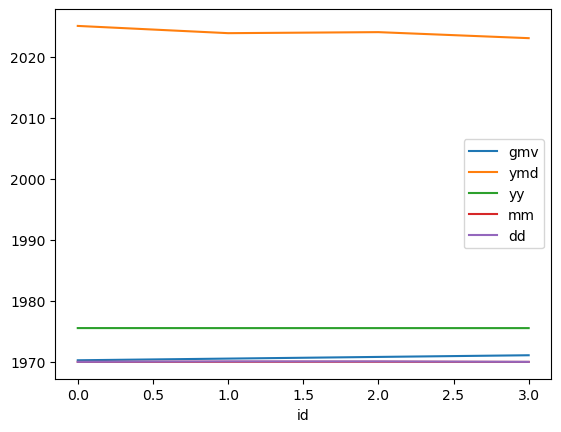

In [44]:
df.index.name = 'id'
print(df)
df.plot()